# Lab 3: Gradient descent and its limits
**Python supplement · Worked solutions · English**

Preserve positivity through a change of variables; visualize gradients and understand the role of the step size.

These two exercises supplement the mathematical lab; they are not
additional required work inside its original 90-minute schedule.
Allow roughly 60–90 minutes, depending on Python experience.

Run the setup cell first, then work from top to bottom. The task functions
are completed in this version. The demonstration cells generate the figures
and run mathematical checks; discussion guidance follows each exercise.

A plot, finite search or successful iteration supplies numerical
evidence. State separately any theorem used to establish existence,
global optimality or an equality case.


This version contains completed code and discussion guidance. All plots and checks can be reproduced with **Restart Kernel and Run All**.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (9, 4), 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'figure.constrained_layout.use': True})

def closed(v):
    """Repeat the first vertex only for plotting."""
    return np.vstack([v, v[0]])

def area(v):
    """Unsigned shoelace area of an ordered simple polygon."""
    return abs(np.sum(v[:, 0]*np.roll(v[:, 1], -1)
                      - v[:, 1]*np.roll(v[:, 0], -1)))/2

def perimeter(v):
    return np.linalg.norm(np.roll(v, -1, axis=0)-v, axis=1).sum()

def outline(ax, v, **kwargs):
    p = closed(v)
    ax.plot(p[:, 0], p[:, 1], **kwargs)
    ax.set_aspect('equal', adjustable='box')




## Exercise 3.1: A fixed-area rectangle by gradient descent

With $ab=A_0>0$, set $a=e^t$, $b=A_0e^{-t}$. The perimeter is
$p(t)=2(e^t+A_0e^{-t})$ and $p'(t)=2(e^t-A_0e^{-t})$.
The exact answer is $t_*=\frac12\log A_0$, $p_*=4\sqrt{A_0}$.

**Code tasks (35–45 minutes).**
1. Implement gradient descent in $t$. Start a trial step at 0.25, halve it
   until the Armijo condition $p(t-\eta g)\leq p(t)-10^{-4}\eta g^2$ holds,
   and stop when $|g|<10^{-9}$ or after 300 iterations.
2. Return the whole history, including the initial value. Plot the perimeter
   and rectangles at the first, middle and last iterates.
3. Test positive and negative starting values and two prescribed areas.

**Return contract:** a one-dimensional array from `rectangle_descent(A0, t0)`.
Limit each line search to 60 trials and raise a clear error if none succeeds.
Logarithmic coordinates keep side lengths positive, but floating-point
exponentials still have a finite range: use the moderate starts below.


In [2]:
def rectangle_descent(A0, t0):
    def p(t):
        return 2*(np.exp(t)+A0*np.exp(-t))
    t = float(t0)
    history = [t]
    for _ in range(300):
        g = 2*(np.exp(t)-A0*np.exp(-t))
        if abs(g) < 1e-9:
            break
        step = 0.25
        for _ in range(60):
            trial = t-step*g
            if abs(trial) < 100 and p(trial) <= p(t)-1e-4*step*g*g:
                break
            step *= 0.5
        else:
            raise RuntimeError('Backtracking did not find an acceptable step.')
        t = trial
        history.append(t)
    return np.array(history)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

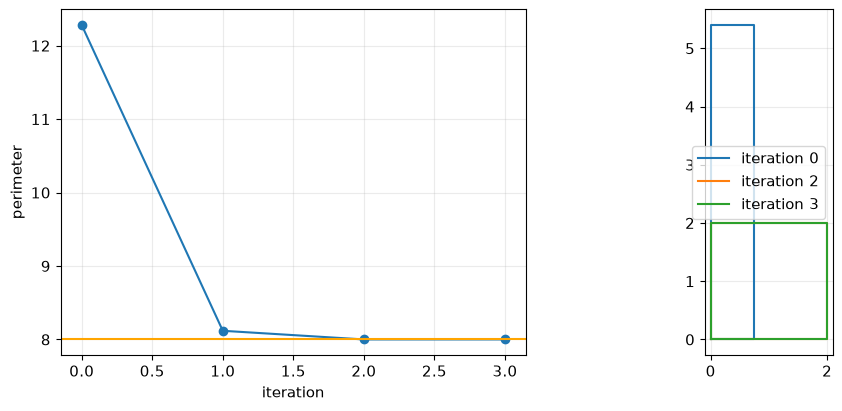

Positivity, area, descent and exact-solution checks passed.


In [3]:
A0 = 4.
history = rectangle_descent(A0, -0.3)
if history is None:
    print('Complete rectangle_descent, then rerun this cell.')
else:
    lengths = np.exp(history)
    widths = A0/lengths
    values = 2*(lengths+widths)
    np.testing.assert_allclose(lengths*widths, A0)
    assert np.all(np.diff(values) <= 1e-11)
    np.testing.assert_allclose(lengths[-1], np.sqrt(A0), atol=1e-6)
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].plot(values, 'o-'); ax[0].axhline(4*np.sqrt(A0), color='orange')
    ax[0].set(xlabel='iteration', ylabel='perimeter')
    for k in sorted(set([0, len(history)//2, len(history)-1])):
        a, b = lengths[k], widths[k]
        outline(ax[1], np.array([[0,0],[a,0],[a,b],[0,b]]), label=f'iteration {k}')
    ax[1].legend(); plt.show()
    for prescribed_area, start in [(1., 2.), (9., -1.)]:
        h = rectangle_descent(prescribed_area, start)
        np.testing.assert_allclose(h[-1], np.log(prescribed_area)/2, atol=1e-6)
    print('Positivity, area, descent and exact-solution checks passed.')


**Explain your observations.** Why does a small gradient alone not prove global optimality in a general problem? What additional convexity and coercivity facts apply here?

**Solution guidance:** Every iterate has positive sides and exact prescribed area up to roundoff. Backtracking decreases the objective. Here p is strictly convex and tends to infinity as |t| grows, so its stationary point is the unique global minimizer. The code checks this known answer; its stopping condition alone is not a general optimality certificate.

## Exercise 3.2: A gradient field and a step that is too large

Let $f(x)=\frac12x^THx$ with
$H=\begin{pmatrix}3&1\\1&2\end{pmatrix}$. Its gradient is $Hx$.
Implement $x_{k+1}=x_k-\eta Hx_k$ with a constant step.

**Code tasks (30–40 minutes).**
1. Complete `quadratic_descent(H, start, step, iterations)` and store all iterates.
2. Overlay normalized **negative-gradient** arrows and trajectories on contours
   of $f$. A normalized arrow shows direction, not gradient magnitude.
3. Use the eigenvalues to calculate the stability threshold
   $\eta<2/\lambda_{\max}(H)$. Compare steps 0.1, 0.5 and 0.6.
   The energy plot must retain the divergent run even if it leaves the contour window.

**Return contract:** array of shape `(iterations+1, 2)`.
Explain the threshold from the factors $1-\eta\lambda_i$ in each eigenvector direction.


In [4]:
def quadratic_descent(H, start, step, iterations=35):
    x = np.array(start, dtype=float)
    history = [x.copy()]
    for _ in range(iterations):
        x = x-step*(H @ x)
        history.append(x.copy())
    return np.array(history)


**Run, visualize and check.** Adapt these plots as requested, and report what changes when you refine the discretization or vary parameters.

Eigenvalues: [1.38196601 3.61803399] critical step: 0.552786404500042


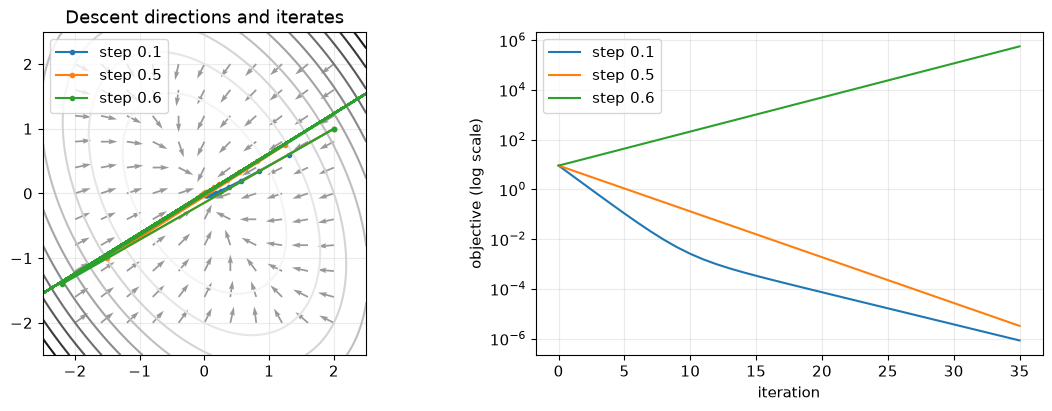

In [5]:
H = np.array([[3., 1.], [1., 2.]])
result = quadratic_descent(H, [2., 1.], 0.1)
if result is None:
    print('Complete quadratic_descent, then rerun this cell.')
else:
    print('Eigenvalues:', np.linalg.eigvalsh(H), 'critical step:', 2/np.linalg.eigvalsh(H)[-1])
    axis = np.linspace(-2.5, 2.5, 100)
    X, Y = np.meshgrid(axis, axis)
    Z = (3*X**2+2*X*Y+2*Y**2)/2
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].contour(X, Y, Z, levels=12, cmap='Greys')
    QX, QY = np.meshgrid(np.linspace(-2, 2, 11), np.linspace(-2, 2, 11))
    GX, GY = -(3*QX+QY), -(QX+2*QY)
    scale = np.maximum(np.hypot(GX, GY), 1e-12)
    ax[0].quiver(QX, QY, GX/scale, GY/scale, alpha=.4)
    for step in (0.1, 0.5, 0.6):
        path = quadratic_descent(H, [2., 1.], step)
        energy = np.einsum('ni,ij,nj->n', path, H, path)/2
        ax[0].plot(path[:, 0], path[:, 1], '.-', label=f'step {step}')
        ax[1].semilogy(np.maximum(energy, 1e-30), label=f'step {step}')
        if step < 2/np.linalg.eigvalsh(H)[-1]:
            assert np.all(np.diff(energy) <= 1e-12)
        else:
            assert energy[-1] > energy[0]
    ax[0].set(xlim=(-2.5,2.5), ylim=(-2.5,2.5), title='Descent directions and iterates')
    ax[0].set_aspect('equal'); ax[0].legend()
    ax[1].set(xlabel='iteration', ylabel='objective (log scale)'); ax[1].legend()
    plt.show()
    np.testing.assert_allclose(quadratic_descent(H, [0., 0.], .1), 0.)


**Explain your observations.** Why can a convex objective still give a divergent numerical iteration? How would the picture change for a saddle such as x²−y²?

**Solution guidance:** Positive Hessian eigenvalues establish strict convexity, but each iteration multiplies an eigenmode by 1−ηλ. A magnitude above one amplifies that mode. For the saddle x²−y², descent amplifies the negative-curvature direction even for a small positive step.

**Before submitting:** restart the kernel, run all cells in order, check axis labels and units, and explain any discrepancy between numerical and exact quantities.